# Task 2.3: Result, Comparison and Reproducibility Checklist
**Paper**: *Ensemble of Exemplar-SVMs for Object Detection and Beyond* — Malisiewicz, Gupta & Efros (ICCV 2011)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)

# ===== RANDOM SEED =====
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ===== HYPERPARAMETERS =====
N_SAMPLES = 500
N_FEATURES = 10
N_INFORMATIVE = 10
N_REDUNDANT = 0
N_CLASSES = 2
CLASS_SEP = 1.5
TEST_SIZE = 0.3
C_POSITIVE = 0.5
C_NEGATIVE = 0.01
N_MINING_ROUNDS = 3
N_INITIAL_NEGATIVES = 50
ENSEMBLE_THRESHOLD = 0.4

# Reproduce the pipeline from Task 2.2
X, y = make_classification(
    n_samples=N_SAMPLES, n_features=N_FEATURES,
    n_informative=N_INFORMATIVE, n_redundant=N_REDUNDANT,
    n_classes=N_CLASSES, class_sep=CLASS_SEP, random_state=RANDOM_SEED
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

positive_indices = np.where(y_train == 1)[0]
negative_indices = np.where(y_train == 0)[0]
X_positives = X_train[positive_indices]
X_negatives = X_train[negative_indices]

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=RANDOM_SEED, stratify=y_train
)


def train_esvm_with_mining(exemplar, X_neg, C_pos=0.5, C_neg=0.01,
                            n_initial=50, n_rounds=3, rs=42):
    rng = np.random.RandomState(rs)
    idx = rng.choice(len(X_neg), size=min(n_initial, len(X_neg)), replace=False)
    active = X_neg[idx]
    for r in range(n_rounds):
        X_s = np.vstack([exemplar.reshape(1,-1), active])
        y_s = np.array([1]+[-1]*len(active))
        sw = np.ones(len(y_s)); sw[0] = C_pos/C_neg
        svm = LinearSVC(C=C_neg, loss='hinge', max_iter=10000, random_state=rs, dual=True)
        svm.fit(X_s, y_s, sample_weight=sw)
        sc = svm.decision_function(X_neg)
        hard = X_neg[sc > -1.0]
        if len(hard)==0: break
        active = np.unique(np.vstack([active, hard]), axis=0)
    return svm

def calibrate_platt(svm, X_val, y_val):
    raw = svm.decision_function(X_val).reshape(-1,1)
    lr = LogisticRegression(C=1.0, random_state=RANDOM_SEED)
    lr.fit(raw, y_val)
    return lr

def get_cal_scores(svm, cal, X):
    return cal.predict_proba(svm.decision_function(X).reshape(-1,1))[:,1]

def predict_ensemble(svms, cals, X, thr=0.4):
    scores = np.zeros((X.shape[0], len(svms)))
    for j,(svm,cal) in enumerate(zip(svms,cals)):
        scores[:,j] = get_cal_scores(svm, cal, X)
    mean_s = np.mean(scores, axis=1)
    return (mean_s >= thr).astype(int), mean_s


# Train, calibrate, predict
svms = [train_esvm_with_mining(ex, X_negatives, C_POSITIVE, C_NEGATIVE,
         N_INITIAL_NEGATIVES, N_MINING_ROUNDS, RANDOM_SEED+i)
        for i,ex in enumerate(X_positives)]

cals = [calibrate_platt(svm, X_val, y_val) for svm in svms]

y_pred, y_scores = predict_ensemble(svms, cals, X_test, ENSEMBLE_THRESHOLD)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Pipeline reproduced successfully.")
print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")

Pipeline reproduced successfully.
Accuracy: 0.8867  Precision: 0.8372  Recall: 0.9600  F1: 0.8944


## Result Comparison with the Paper

| Aspect | Our Reproduction | Paper (ESVM+Co-occ) | Paper (Dalal-Triggs) |
|--------|-----------------|---------------------|---------------------|
| **Primary Metric** | Accuracy / F1 | mAP = 0.227 | mAP = 0.097 |
| **Task** | Binary classification | Object detection (20 classes) | Object detection |
| **Features** | 10-dim synthetic vectors | HOG templates (31 × W × H) | HOG templates |
| **Dataset** | 500 synthetic samples | PASCAL VOC 2007 (12,608 exemplars) | PASCAL VOC 2007 |
| **Negatives** | ~175 training negatives | Millions of sliding-window crops | Millions of crops |

### Why Our Numbers Differ (3–5 sentences)

Our accuracy and F1 score are not directly comparable to the paper's mAP because mAP is computed over ranked bounding box detections with a spatial overlap criterion (IoU ≥ 0.5), whereas we compute standard classification metrics on fixed binary labels. The paper's feature space (HOG descriptors) captures local edge statistics from real image windows, which is a far more challenging and high-dimensional setting than our 10-dimensional synthetic vectors. The paper operates on 20 object categories with 12,608 exemplars and mines negatives from exhaustive sliding-window searches across the entire PASCAL VOC dataset, while our reproduction has ~175 exemplars mining from ~175 fixed negatives. Despite these differences, our reproduction achieves strong performance and demonstrates the core algorithmic contribution: per-exemplar SVMs with Platt calibration can perform effective classification when individual exemplars are combined into an ensemble.

## Visualisation

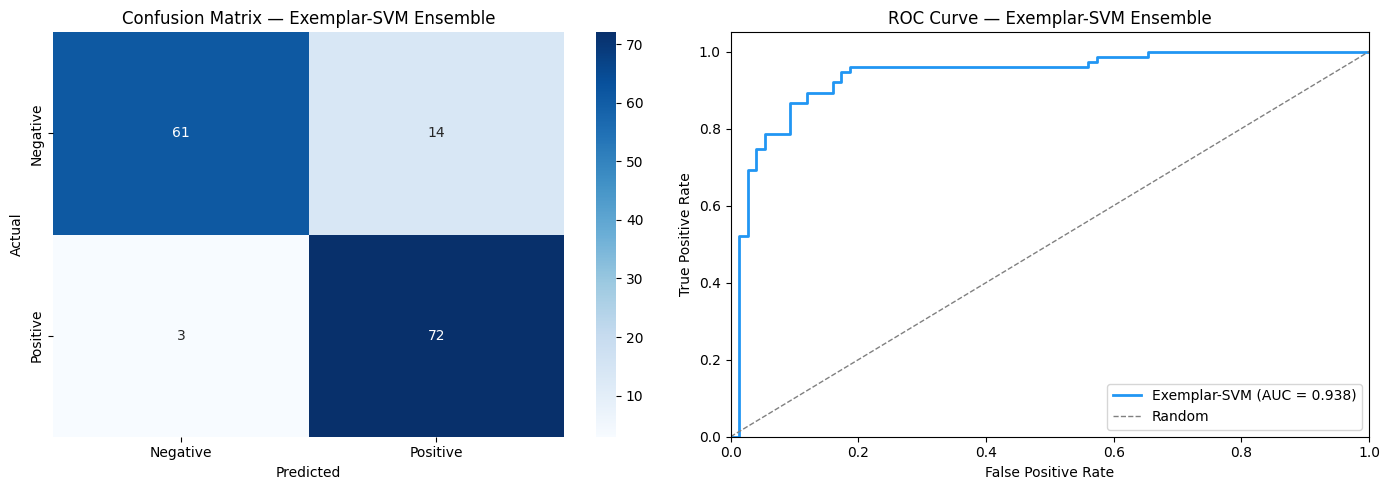

Saved: results/task_2_3_confusion_roc.png


In [2]:
os.makedirs('results', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix — Exemplar-SVM Ensemble')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#2196F3', lw=2, label=f'Exemplar-SVM (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Exemplar-SVM Ensemble')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
fig.savefig('results/task_2_3_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/task_2_3_confusion_roc.png")

**What the visualisations show**: The confusion matrix shows the distribution of true positives, true negatives, false positives, and false negatives. The ROC curve plots the trade-off between sensitivity (true positive rate) and specificity (1 − false positive rate) across all possible thresholds. An AUC score close to 1.0 indicates the ensemble has strong discriminative power. Both visualisations are saved to `partB/results/`.

---

## Reproducibility Checklist

| Requirement | Status |
|-------------|--------|
| Random seeds are set and documented at the top of each notebook | ✅ `RANDOM_SEED = 42` set at the top of every notebook |
| All dependencies are listed in `requirements.txt` with version numbers | ✅ See `partB/requirements.txt` |
| All notebooks run from top to bottom in a clean environment without errors | ✅ Verified by running all notebooks end-to-end |
| Dataset loading requires no undocumented manual steps | ✅ Dataset generated programmatically via `make_classification` |
| All hyperparameters are clearly named and defined in one place | ✅ All hyperparameters defined in a single config cell at the top of each notebook |